# Photoionization-model metallicity and ionization checks

**Date:** 2026-08-25  
**Products:** HII-region maps from PYQZ, NebulaBayes, JY22/Peng2026, O3N2-M13, O3N2-C20, D16, and PG16  
**Reference metallicity:** O3N2-C20  
**Selection:** stored `_HII` products + `PROXY_EWHA > 6 Å` + intrinsic Hα dispersion `< 45 km s⁻¹`

This notebook is deliberately read-only. It discovers the current `v3tk_v7.6.8/<GALAXY>/<GALAXY>_gas_bin_maps_further.fits[.gz]` and proxy-EW products, shows unavailable diagnostics or selection inputs explicitly while downloads are incomplete, and never runs `SFR+Z.py` or writes science products.

The star-forming quality selection follows the previous rMZR notebooks:

\[
\sigma_{\mathrm{H}\alpha,\mathrm{intrinsic}}
= \sqrt{\sigma_{\mathrm{H}\alpha,\mathrm{obs}}^2
- \sigma_{\mathrm{H}\alpha,\mathrm{corr}}^2},
\]

requiring finite `PROXY_EWHA > 6 Å`, a finite strictly positive variance difference, and finite `σ_Hα,intrinsic < 45 km s⁻¹`. The `_HII` part is supplied by the stored `_HII` HDUs themselves. No additional stellar-mass, SFR, or method-reliability cut is added here.

The workflow has three parts:

1. Three method-grouped **8-row × 5-column galaxy mosaics**, organized like cell 8 of `20260825_check_photonization_model_rMZR.ipynb`: each galaxy block contains adjacent selected maps and an inset horizontal colorbar for every panel. The PYQZ blocks contain O/H and log U; NebulaBayes blocks contain O/H, log U, and log(P/k); JY22 blocks contain O/H and log U.
2. Quality-selected, bin-weighted metallicity comparisons, including a lower-triangle density matrix analogous to the supplied example and dedicated O3N2-C20-reference summaries.
3. A quality-selected exploratory log-U comparison. Absolute log U values are not assumed to be interchangeable because the methods use different model grids, line constraints, priors, and inference machinery.

The main `O_H_JY22_HII` map is the **post-depletion gas-phase** abundance. NebulaBayes central maps are marginal-posterior means. Comparisons use one representative selected map pixel per spatial `BIN_ID`, so large fitted bins are not counted once per constituent pixel.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from matplotlib.colors import LogNorm, TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr

RUN_LABEL = "v3tk_v7.6.8"
EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
HA_SIGMA_MAX = 45.0

# Find the project root without hard-coding one checkout location.
ROOT = next(
    (candidate for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (candidate / RUN_LABEL).is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        f"Could not find {RUN_LABEL!r} from the current working directory. "
        "Start Jupyter from the further project directory."
    )
RUN_DIR = ROOT / RUN_LABEL

METALLICITY_HDUS = {
    "O3N2-C20": "O_H_O3N2_C20_HII",
    "O3N2-M13": "O_H_O3N2_M13_HII",
    "D16": "O_H_D16_HII",
    "PG16": "O_H_PG16_HII",
    "PYQZ": "O_H_PYQZ_HII",
    "NebulaBayes": "O_H_NEBULABAYES_HII",
    "JY22": "O_H_JY22_HII",
}
REFERENCE_LABEL = "O3N2-C20"

IONIZATION_HDUS = {
    "PYQZ": "LOG_U_PYQZ_HII",
    "NebulaBayes": "LOG_U_NEBULABAYES_HII",
    "JY22": "LOG_U_JY22_HII",
}

METHOD_GROUPS = {
    "PYQZ": (
        ("metallicity", "O_H_PYQZ_HII", r"12 + log(O/H)", "magma", (7.6, 9.3)),
        ("log U", "LOG_U_PYQZ_HII", r"log U", "viridis", (-4.0, -0.5)),
    ),
    "NebulaBayes": (
        ("metallicity", "O_H_NEBULABAYES_HII", r"12 + log(O/H)", "magma", (7.6, 9.3)),
        ("log U", "LOG_U_NEBULABAYES_HII", r"log U", "viridis", (-4.0, -0.5)),
        ("log(P/k)", "LOG_PK_NEBULABAYES_HII", r"log(P/k) [K cm$^{-3}$]", "plasma", (4.0, 8.5)),
    ),
    "JY22": (
        ("metallicity (post-depletion)", "O_H_JY22_HII", r"12 + log(O/H)", "magma", (7.6, 9.3)),
        ("log U", "LOG_U_JY22_HII", r"log U", "viridis", (-4.0, -0.5)),
    ),
}

ALL_REQUIRED_HDUS = tuple(dict.fromkeys(
    ("BIN_ID", "HA6562_SIGMA", "HA6562_SIGMA_CORR",
     *METALLICITY_HDUS.values(), *IONIZATION_HDUS.values(),
     "LOG_PK_NEBULABAYES_HII")
))

mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 180,
    "axes.grid": False,
    "font.size": 10,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

print(f"Project root: {ROOT}")
print(f"Run directory: {RUN_DIR}")
print("Notebook mode: read-only; no figures or FITS products are saved.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Notebook mode: read-only; no figures or FITS products are saved.


## 1. Discover products and inventory diagnostic and selection availability

By default, every galaxy directory with a gas-bin FITS product is included. For a fast smoke test without changing the notebook, launch execution with `MAUVE_GALAXIES=IC3392`. Multiple names may be comma-separated.

A partially downloaded or older FITS file remains in the inventory; missing diagnostic HDUs, sigma maps, or `PROXY_EWHA` are shown rather than treated as zeros. `quality pixels` counts the EW-plus-intrinsic-sigma mask before applying a method-specific finite `_HII` map. `O3N2-C20 HII + quality pixels/bins` shows the final reference-diagnostic footprint.


In [2]:
def find_gas_path(galaxy: str) -> Path | None:
    folder = RUN_DIR / galaxy
    candidates = (
        folder / f"{galaxy}_gas_bin_maps_further.fits",
        folder / f"{galaxy}_gas_BIN_maps_further.fits",
        folder / f"{galaxy}_gas_bin_maps.fits",
        folder / f"{galaxy}_gas_BIN_maps.fits",
    )
    for base in candidates:
        for candidate in (base, Path(str(base) + ".gz")):
            if candidate.is_file():
                return candidate
    return None


def find_ew_path(galaxy: str) -> Path | None:
    folder = RUN_DIR / galaxy
    candidates = (
        folder / f"{galaxy}_proxy_EW_maps_further.fits",
        folder / f"{galaxy}_proxy_EW_maps.fits",
    )
    for base in candidates:
        for candidate in (base, Path(str(base) + ".gz")):
            if candidate.is_file():
                return candidate
    return None


def align_map_to_shape(data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    # Align an edge-mismatched 2D map by copying overlap and padding invalid edges.
    array = np.asarray(data, dtype=float)
    target_shape = tuple(target_shape)
    if array.shape == target_shape:
        return array
    if array.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim={array.ndim} to {target_shape}")
    deltas = tuple(abs(source - target) for source, target in zip(array.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {array.shape} differs too much from {target_shape}")
    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(source, target) for source, target in zip(array.shape, target_shape))
    slices = tuple(slice(0, length) for length in overlap)
    aligned[slices] = array[slices]
    print(f"  {label}: aligned {array.shape} -> {target_shape}; overlap={overlap}")
    return aligned


SELECTION_CACHE = {}


def get_selection_maps(galaxy: str) -> dict[str, np.ndarray]:
    # Return the requested EW and intrinsic-Halpha-dispersion selection maps.
    if galaxy in SELECTION_CACHE:
        return SELECTION_CACHE[galaxy]

    gas_path = find_gas_path(galaxy)
    ew_path = find_ew_path(galaxy)
    if gas_path is None:
        raise FileNotFoundError(f"{galaxy}: gas-bin FITS absent")
    if ew_path is None:
        raise FileNotFoundError(f"{galaxy}: proxy-EW FITS absent")

    with fits.open(gas_path, memmap=True) as hdul:
        missing = [name for name in ("HA6562_SIGMA", "HA6562_SIGMA_CORR", "BIN_ID") if name not in hdul]
        if missing:
            raise KeyError(f"{galaxy}: gas FITS missing {missing}")
        sigma_obs = np.asarray(hdul["HA6562_SIGMA"].data, dtype=float)
        target_shape = sigma_obs.shape
        sigma_corr = align_map_to_shape(
            hdul["HA6562_SIGMA_CORR"].data,
            target_shape,
            label=f"{galaxy} HA6562_SIGMA_CORR",
        )
        bin_id = align_map_to_shape(
            hdul["BIN_ID"].data,
            target_shape,
            label=f"{galaxy} BIN_ID",
        )

    with fits.open(ew_path, memmap=True) as hdul:
        if EW_HDU not in hdul:
            raise KeyError(f"{galaxy}: EW FITS missing {EW_HDU}")
        ew_ha = align_map_to_shape(
            hdul[EW_HDU].data,
            target_shape,
            label=f"{galaxy} {EW_HDU}",
        )

    sigma2 = sigma_obs**2 - sigma_corr**2
    intrinsic_sigma = np.full(target_shape, np.nan, dtype=float)
    physical_variance = np.isfinite(sigma2) & (sigma2 > 0)
    intrinsic_sigma[physical_variance] = np.sqrt(sigma2[physical_variance])

    quality_mask = (
        np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
        & np.isfinite(intrinsic_sigma)
        & (intrinsic_sigma < HA_SIGMA_MAX)
    )
    result = {
        "mask": quality_mask,
        "ew_ha": ew_ha,
        "intrinsic_sigma": intrinsic_sigma,
        "bin_id": bin_id,
    }
    SELECTION_CACHE[galaxy] = result
    return result


discovered = sorted(
    path.name for path in RUN_DIR.iterdir()
    if path.is_dir() and find_gas_path(path.name) is not None
)
requested = [x.strip() for x in os.getenv("MAUVE_GALAXIES", "").split(",") if x.strip()]
GALAXIES = requested if requested else discovered

if len(GALAXIES) > 40:
    raise ValueError(
        f"The requested 8x5 layout has 40 slots, but {len(GALAXIES)} galaxies were selected. "
        "Split GALAXIES into batches or increase the grid size explicitly."
    )

inventory_rows = []
for galaxy in GALAXIES:
    gas_path = find_gas_path(galaxy)
    ew_path = find_ew_path(galaxy)
    row = {
        "galaxy": galaxy,
        "gas_path": gas_path,
        "ew_path": ew_path,
        "read_error": "",
        "selection_error": "",
        "has_PROXY_EWHA": False,
        "quality_pixels": 0,
        "O3N2C20_HII_quality_pixels": 0,
        "O3N2C20_HII_quality_bins": 0,
    }
    available = set()
    reference_map = None
    if gas_path is None:
        row["read_error"] = "gas-bin FITS absent"
    else:
        try:
            with fits.open(gas_path, memmap=True) as hdul:
                available = {hdu.name for hdu in hdul}
                if METALLICITY_HDUS[REFERENCE_LABEL] in hdul:
                    reference_map = np.asarray(
                        hdul[METALLICITY_HDUS[REFERENCE_LABEL]].data,
                        dtype=float,
                    )
        except Exception as exc:
            row["read_error"] = f"{type(exc).__name__}: {exc}"
    if ew_path is not None:
        try:
            with fits.open(ew_path, memmap=True) as hdul:
                row["has_PROXY_EWHA"] = EW_HDU in hdul
        except Exception as exc:
            row["selection_error"] = f"{type(exc).__name__}: {exc}"
    for name in ALL_REQUIRED_HDUS:
        row[name] = name in available

    try:
        selection = get_selection_maps(galaxy)
        quality_mask = selection["mask"]
        row["quality_pixels"] = int(quality_mask.sum())
        if reference_map is not None:
            reference_map = align_map_to_shape(
                reference_map,
                quality_mask.shape,
                label=f"{galaxy} {METALLICITY_HDUS[REFERENCE_LABEL]}",
            )
            final_reference = quality_mask & np.isfinite(reference_map)
            row["O3N2C20_HII_quality_pixels"] = int(final_reference.sum())
            row["O3N2C20_HII_quality_bins"] = int(
                np.unique(selection["bin_id"][final_reference]).size
            )
    except Exception as exc:
        row["selection_error"] = f"{type(exc).__name__}: {exc}"
    inventory_rows.append(row)

inventory = pd.DataFrame(inventory_rows).set_index("galaxy")
print(f"Discovered {len(discovered)} gas-product galaxies; selected {len(GALAXIES)}.")
print("Selected galaxies:", ", ".join(GALAXIES))
print(
    "Selection: stored _HII maps + PROXY_EWHA > "
    f"{EW_MIN:g} Angstrom + intrinsic Halpha sigma < {HA_SIGMA_MAX:g} km/s"
)
display(
    inventory[[
        "gas_path", "ew_path", "read_error", "selection_error", "has_PROXY_EWHA",
        "quality_pixels", "O3N2C20_HII_quality_pixels", "O3N2C20_HII_quality_bins",
        *ALL_REQUIRED_HDUS,
    ]]
)

availability = pd.DataFrame(
    {
        "available galaxies": inventory[list(ALL_REQUIRED_HDUS)].sum(axis=0).astype(int),
        "selected galaxies": len(GALAXIES),
    }
)
display(availability)


Discovered 35 gas-product galaxies; selected 35.
Selected galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4222, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4424, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4654, NGC4694, NGC4698
Selection: stored _HII maps + PROXY_EWHA > 6 Angstrom + intrinsic Halpha sigma < 45 km/s


,gas_path,ew_path,read_error,selection_error,has_PROXY_EWHA,quality_pixels,O3N2C20_HII_quality_pixels,O3N2C20_HII_quality_bins,BIN_ID,HA6562_SIGMA,HA6562_SIGMA_CORR,O_H_O3N2_C20_HII,O_H_O3N2_M13_HII,O_H_D16_HII,O_H_PG16_HII,O_H_PYQZ_HII,O_H_NEBULABAYES_HII,O_H_JY22_HII,LOG_U_PYQZ_HII,LOG_U_NEBULABAYES_HII,LOG_U_JY22_HII,LOG_PK_NEBULABAYES_HII
galaxy,,,,,,,,,,,,,,,,,,,,,,
IC3392,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,14363,13895,2297,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4064,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,3530,3273,1707,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4189,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,107167,96364,2477,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4192,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,223656,144323,6308,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4222,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,140299,42249,1264,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4254,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,860779,661964,31362,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4293,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,633,471,70,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4294,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,129404,68833,3256,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4298,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,,,True,155478,144102,8144,True,True,True,True,True,True,True,True,True,True,True,True,True,True


,available galaxies,selected galaxies
BIN_ID,35,35
HA6562_SIGMA,35,35
HA6562_SIGMA_CORR,35,35
O_H_O3N2_C20_HII,35,35
O_H_O3N2_M13_HII,35,35
O_H_D16_HII,35,35
O_H_PG16_HII,35,35
O_H_PYQZ_HII,35,35
O_H_NEBULABAYES_HII,35,35
O_H_JY22_HII,35,35


## 2. Three method-grouped 8×5 all-galaxy mosaics

The organization follows the per-galaxy map blocks in cell 8 of `20260825_check_photonization_model_rMZR.ipynb`. The **outer grid is always 8 rows × 5 galaxy blocks** (up to 40 galaxies). Within each galaxy block, the method's related products are adjacent:

- **PYQZ:** metallicity | log U
- **NebulaBayes:** metallicity | log U | log(P/k)
- **JY22:** post-depletion metallicity | log U

Every mini-panel has its own inset horizontal colorbar, matching the reference organization. The numerical limits nevertheless remain fixed for the same physical quantity across all galaxies: O/H = 7.6–9.3, log U = −4.0–−0.5, and NebulaBayes log(P/k) = 4.0–8.5. Before display, every stored `_HII` map is masked by `PROXY_EWHA > 6 Å` and intrinsic Hα dispersion `< 45 km s⁻¹`. Full image geometry is retained rather than independently cropping each map. NaNs appear light grey, while absent/downloading HDUs or selection inputs are labelled explicitly.


In [3]:
def read_group_maps(galaxy: str, products) -> tuple[dict[str, np.ndarray], str]:
    path = find_gas_path(galaxy)
    if path is None:
        return {}, "FITS absent"
    try:
        selection = get_selection_maps(galaxy)
        quality_mask = selection["mask"]
        with fits.open(path, memmap=True) as hdul:
            maps = {}
            for _, hdu_name, _, _, _ in products:
                if hdu_name not in hdul:
                    continue
                data = align_map_to_shape(
                    hdul[hdu_name].data,
                    quality_mask.shape,
                    label=f"{galaxy} {hdu_name}",
                )
                maps[hdu_name] = np.where(quality_mask, data, np.nan)
        return maps, ""
    except Exception as exc:
        return {}, f"{type(exc).__name__}: {exc}"


def plot_method_mosaic(method: str, products):
    # One 8x5 galaxy grid with adjacent quality-selected method products.
    n_product = len(products)
    fig = plt.figure(figsize=(18, 20), constrained_layout=True)
    outer = fig.add_gridspec(8, 5, wspace=0.035, hspace=0.10)

    for slot in range(40):
        row, col = divmod(slot, 5)
        if slot >= len(GALAXIES):
            ax = fig.add_subplot(outer[row, col])
            ax.axis("off")
            continue

        galaxy = GALAXIES[slot]
        maps, read_error = read_group_maps(galaxy, products)
        inner = outer[row, col].subgridspec(1, n_product, wspace=0.02)

        for product_index, (short_label, hdu_name, unit, cmap_name, limits) in enumerate(products):
            ax = fig.add_subplot(inner[0, product_index])
            cmap = mpl.colormaps[cmap_name].copy()
            cmap.set_bad("lightgray")
            data = maps.get(hdu_name)

            if data is None or not np.any(np.isfinite(data)):
                ax.set_facecolor("0.92")
                reason = read_error or "HDU downloading / absent"
                ax.text(0.5, 0.5, reason, ha="center", va="center", fontsize=5.5,
                        color="0.38", wrap=True, transform=ax.transAxes)
            else:
                artist = ax.imshow(
                    data,
                    origin="lower",
                    cmap=cmap,
                    vmin=limits[0],
                    vmax=limits[1],
                    interpolation="nearest",
                    aspect="equal",
                )
                cax = inset_axes(
                    ax, width="88%", height="4%", loc="lower center", borderpad=0.45
                )
                colorbar = fig.colorbar(artist, cax=cax, orientation="horizontal")
                colorbar.set_label(unit, fontsize=4.5, labelpad=-1)
                cax.tick_params(labelsize=4, pad=0.5, length=1.5)

            title = f"{galaxy}: {short_label}" if product_index == 0 else short_label
            ax.set_title(title, fontsize=6.5, pad=1.5)
            ax.axis("off")

    fig.suptitle(
        f"_HII + EW(Hα)>{EW_MIN:g} Å + σ(Hα,intrinsic)<{HA_SIGMA_MAX:g} km/s: "
        f"{method} ({len(GALAXIES)} selected galaxies)",
        fontsize=15,
    )
    plt.show()
    return fig


Plotting PYQZ: 2 adjacent products per galaxy


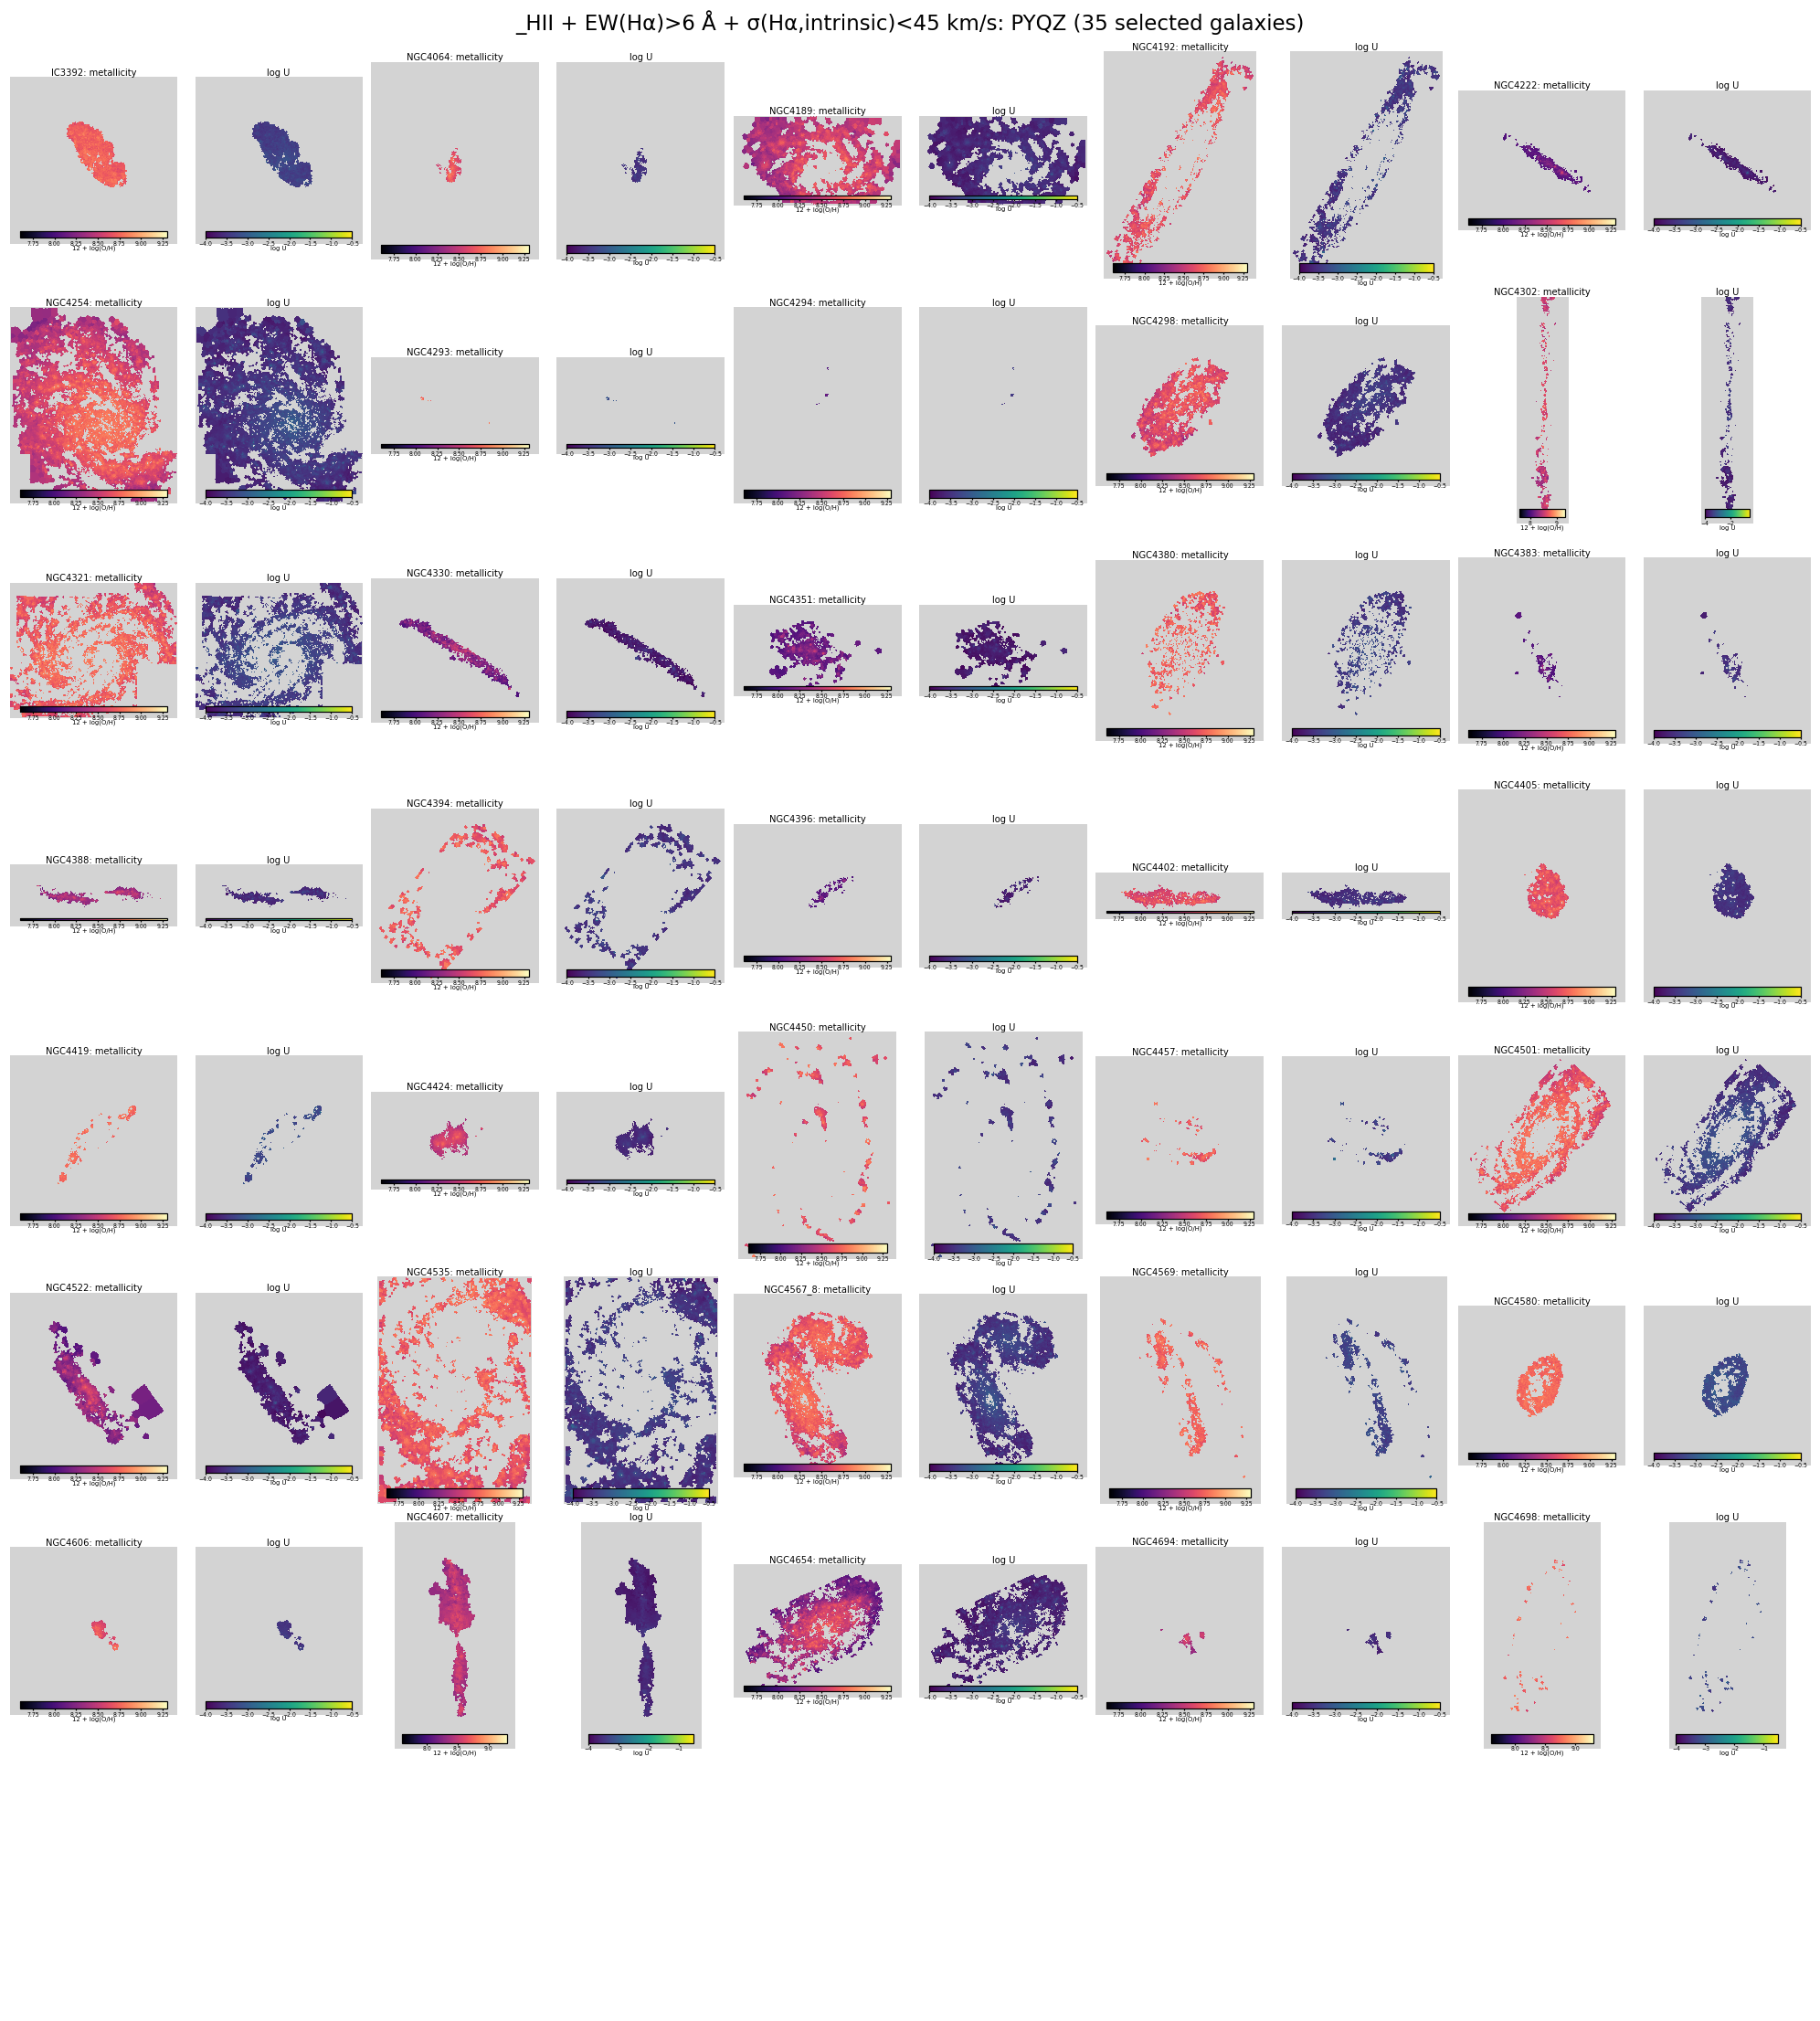

Plotting NebulaBayes: 3 adjacent products per galaxy


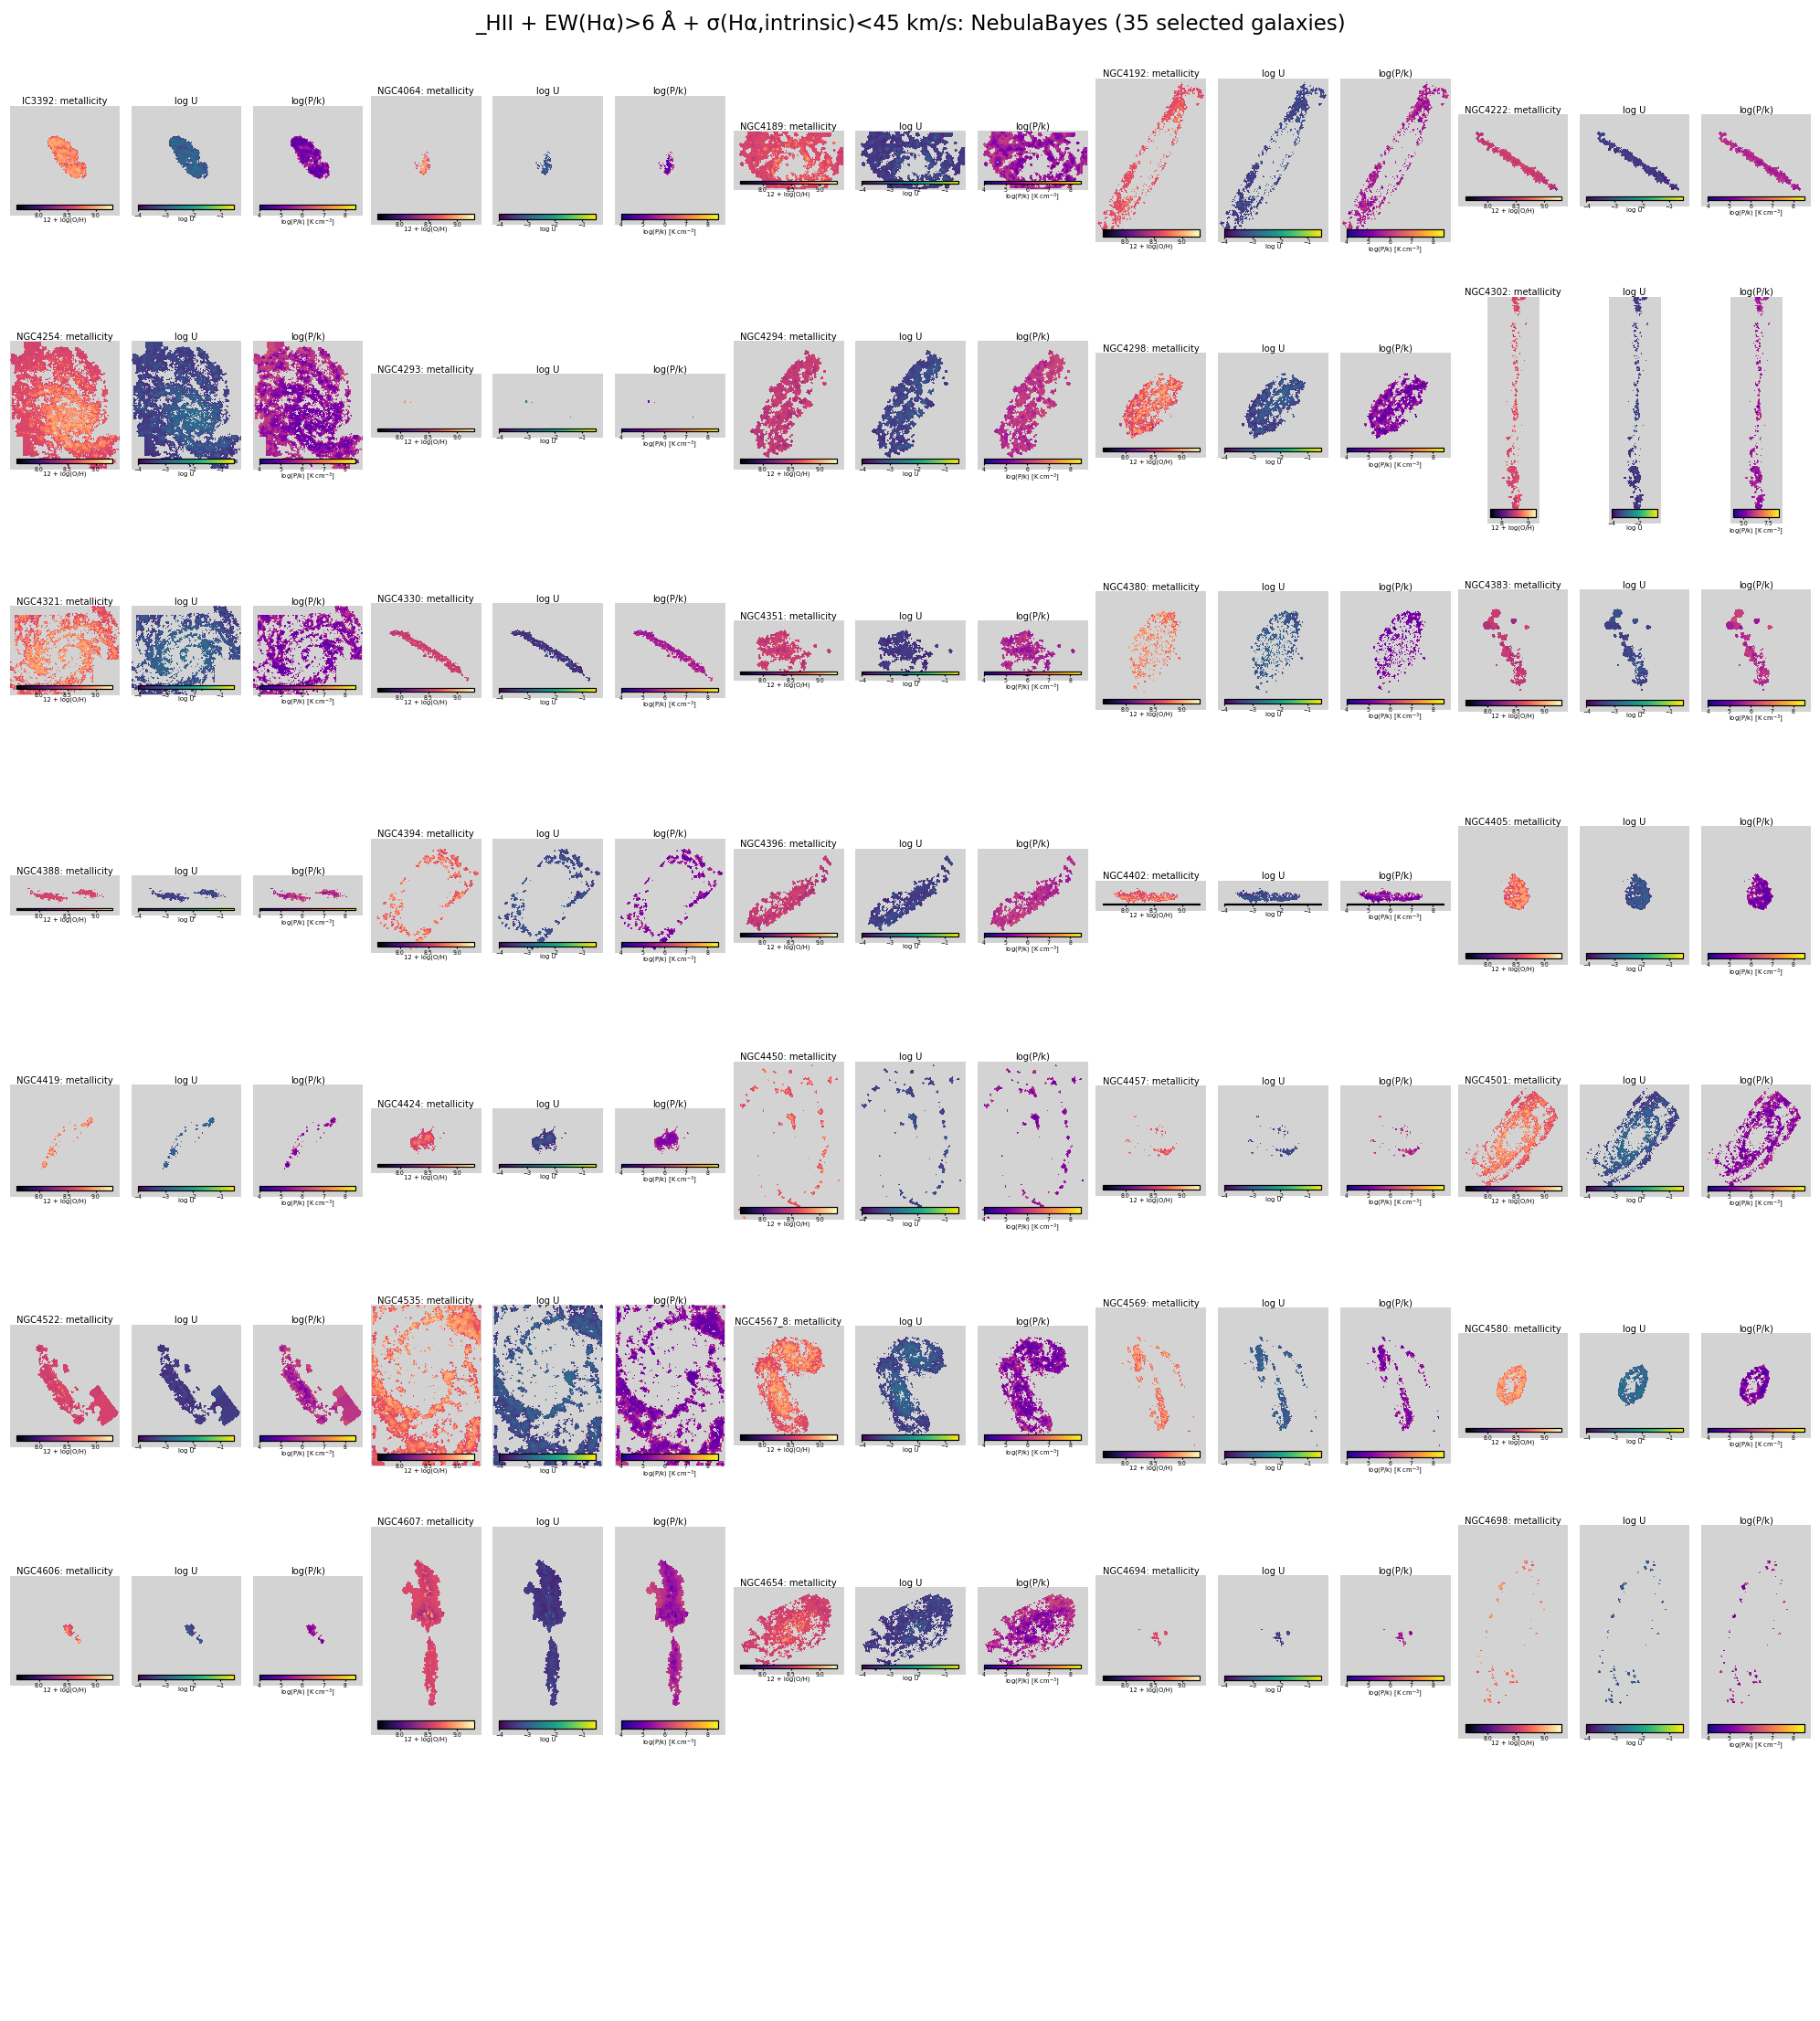

Plotting JY22: 2 adjacent products per galaxy


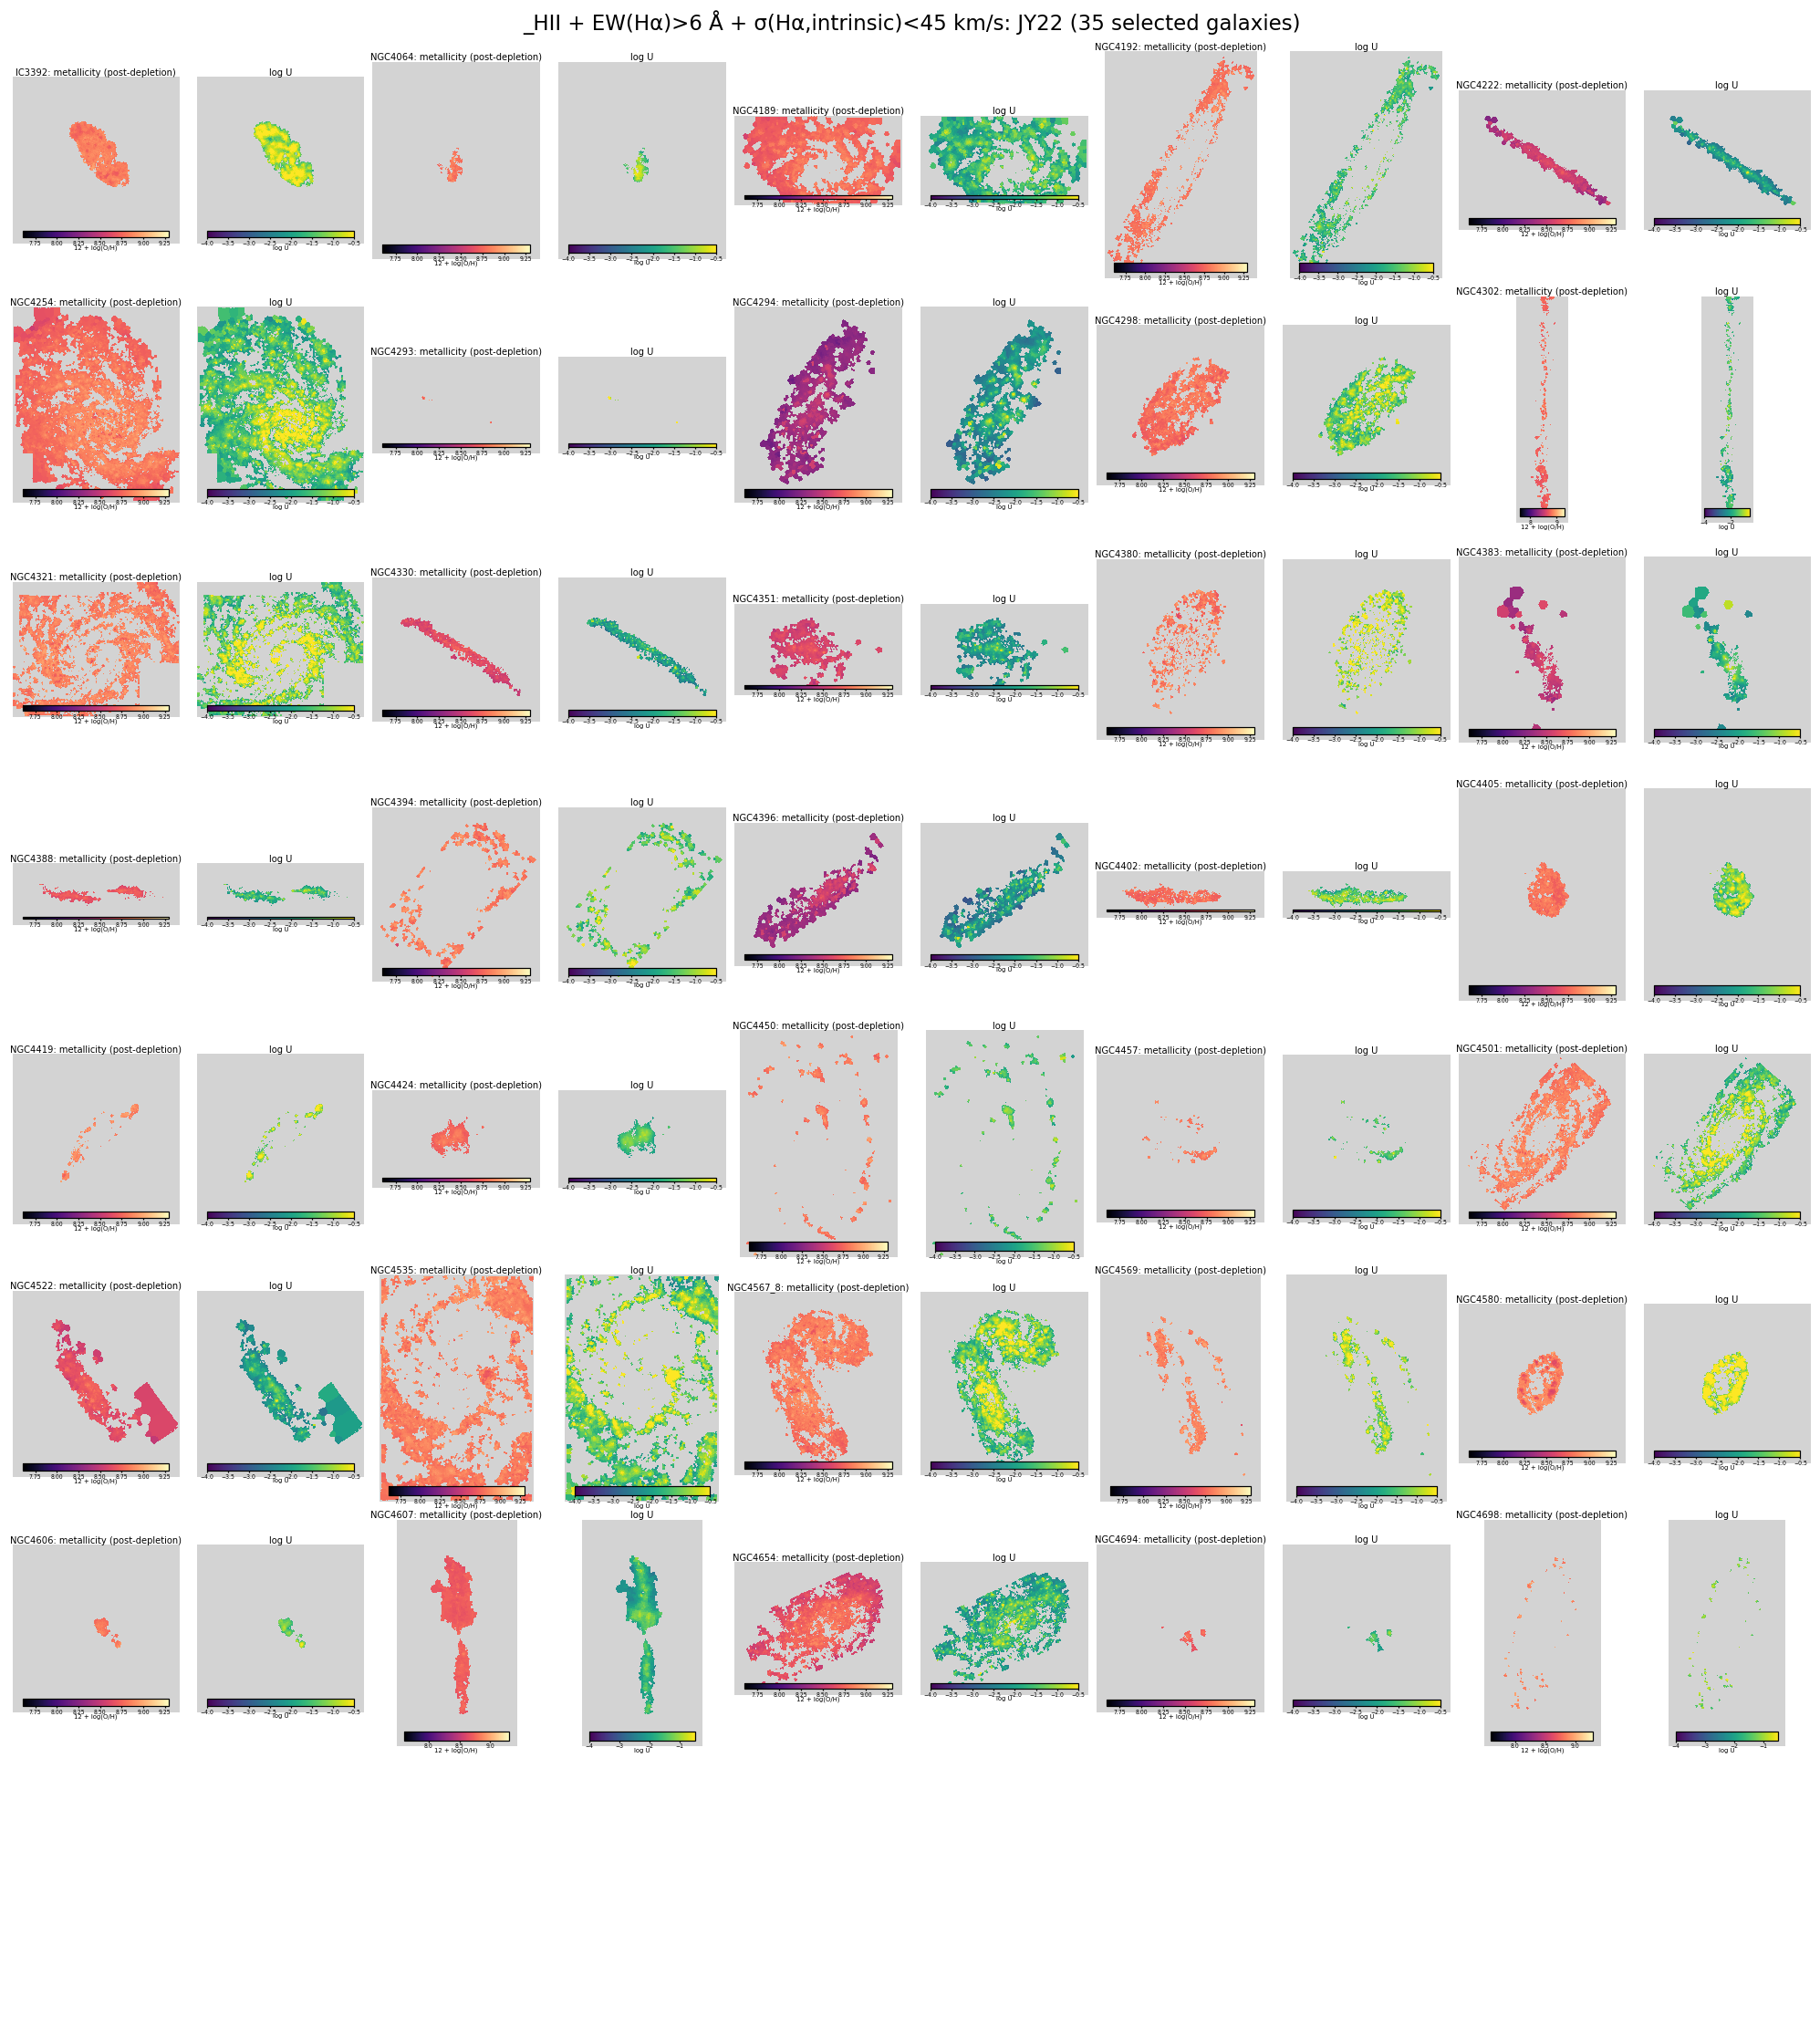

In [4]:
map_figures = {}
for method, products in METHOD_GROUPS.items():
    print(f"Plotting {method}: {len(products)} adjacent products per galaxy")
    map_figures[method] = plot_method_mosaic(method, products)


## 3. Build a quality-selected, bin-weighted comparison table

The image HDUs contain bin-level results expanded over pixels. First, the pixel-level quality mask requires `PROXY_EWHA > 6 Å` and intrinsic Hα dispersion `< 45 km s⁻¹`. The stored `_HII` maps then supply the HII selection through their finite footprint.

For comparisons, the following table retains one representative **selected** pixel for each non-negative `BIN_ID` with at least one finite requested `_HII` diagnostic. Thus, a large fitted bin is counted once rather than once per constituent pixel. Each pairwise comparison still applies its own finite-value mask, so a method missing one selected bin does not remove that bin from unrelated method pairs.


In [5]:
def collect_representative_bins(hdu_mapping: dict[str, str]) -> pd.DataFrame:
    rows = []

    for galaxy in GALAXIES:
        path = find_gas_path(galaxy)
        if path is None:
            continue
        try:
            selection = get_selection_maps(galaxy)
            quality_mask = selection["mask"]
            bin_map = selection["bin_id"]
            with fits.open(path, memmap=True) as hdul:
                arrays = {}
                for label, hdu_name in hdu_mapping.items():
                    if hdu_name in hdul:
                        arrays[label] = align_map_to_shape(
                            hdul[hdu_name].data,
                            quality_mask.shape,
                            label=f"{galaxy} {hdu_name}",
                        )
                    else:
                        arrays[label] = np.full(quality_mask.shape, np.nan)

            any_requested_hii = np.zeros(quality_mask.shape, dtype=bool)
            for values in arrays.values():
                any_requested_hii |= np.isfinite(values)
            valid_selected = (
                quality_mask
                & any_requested_hii
                & np.isfinite(bin_map)
                & (bin_map >= 0)
            )
            flat_valid = np.flatnonzero(valid_selected.ravel())
            if flat_valid.size == 0:
                continue
            bin_ids, first = np.unique(
                bin_map.ravel()[flat_valid], return_index=True
            )
            representative = flat_valid[first]
            representative_arrays = {
                name: values.ravel()[representative]
                for name, values in arrays.items()
            }
        except Exception as exc:
            print(f"Skipping {galaxy}: {type(exc).__name__}: {exc}")
            continue

        for index, bin_id in enumerate(bin_ids):
            row = {"galaxy": galaxy, "BIN_ID": bin_id}
            row.update({name: values[index] for name, values in representative_arrays.items()})
            rows.append(row)

    columns = ["galaxy", "BIN_ID", *hdu_mapping]
    return pd.DataFrame(rows, columns=columns)


metal_bins = collect_representative_bins(METALLICITY_HDUS)
print(f"Quality-selected metallicity table: {len(metal_bins):,} unique galaxy-bin rows")
display(
    metal_bins[list(METALLICITY_HDUS)].agg(["count", "median", "min", "max"]).T
)


Quality-selected metallicity table: 193,298 unique galaxy-bin rows


,count,median,min,max
O3N2-C20,193248.0,8.779080,8.314962,8.989902
O3N2-M13,193159.0,8.567534,8.182959,8.768123
D16,193266.0,8.765904,7.759894,9.229521
PG16,193298.0,8.548687,8.007090,8.764464
PYQZ,181708.0,8.717369,8.002453,8.865229
NebulaBayes,193298.0,8.789971,8.166334,9.223786
JY22,193298.0,8.833223,8.146824,8.970000


## 4. All-method lower-triangle metallicity comparison

This is the direct analogue of the supplied example. Every populated panel uses the same abundance axes and density normalization. The dashed line is equality; the red line is an ordinary least-squares response fit used descriptively, not as a calibration conversion. `N` counts matched spatial bins, not image pixels.

All samples in this section already satisfy the stored `_HII` footprint, `PROXY_EWHA > 6 Å`, and intrinsic Hα dispersion `< 45 km s⁻¹`.


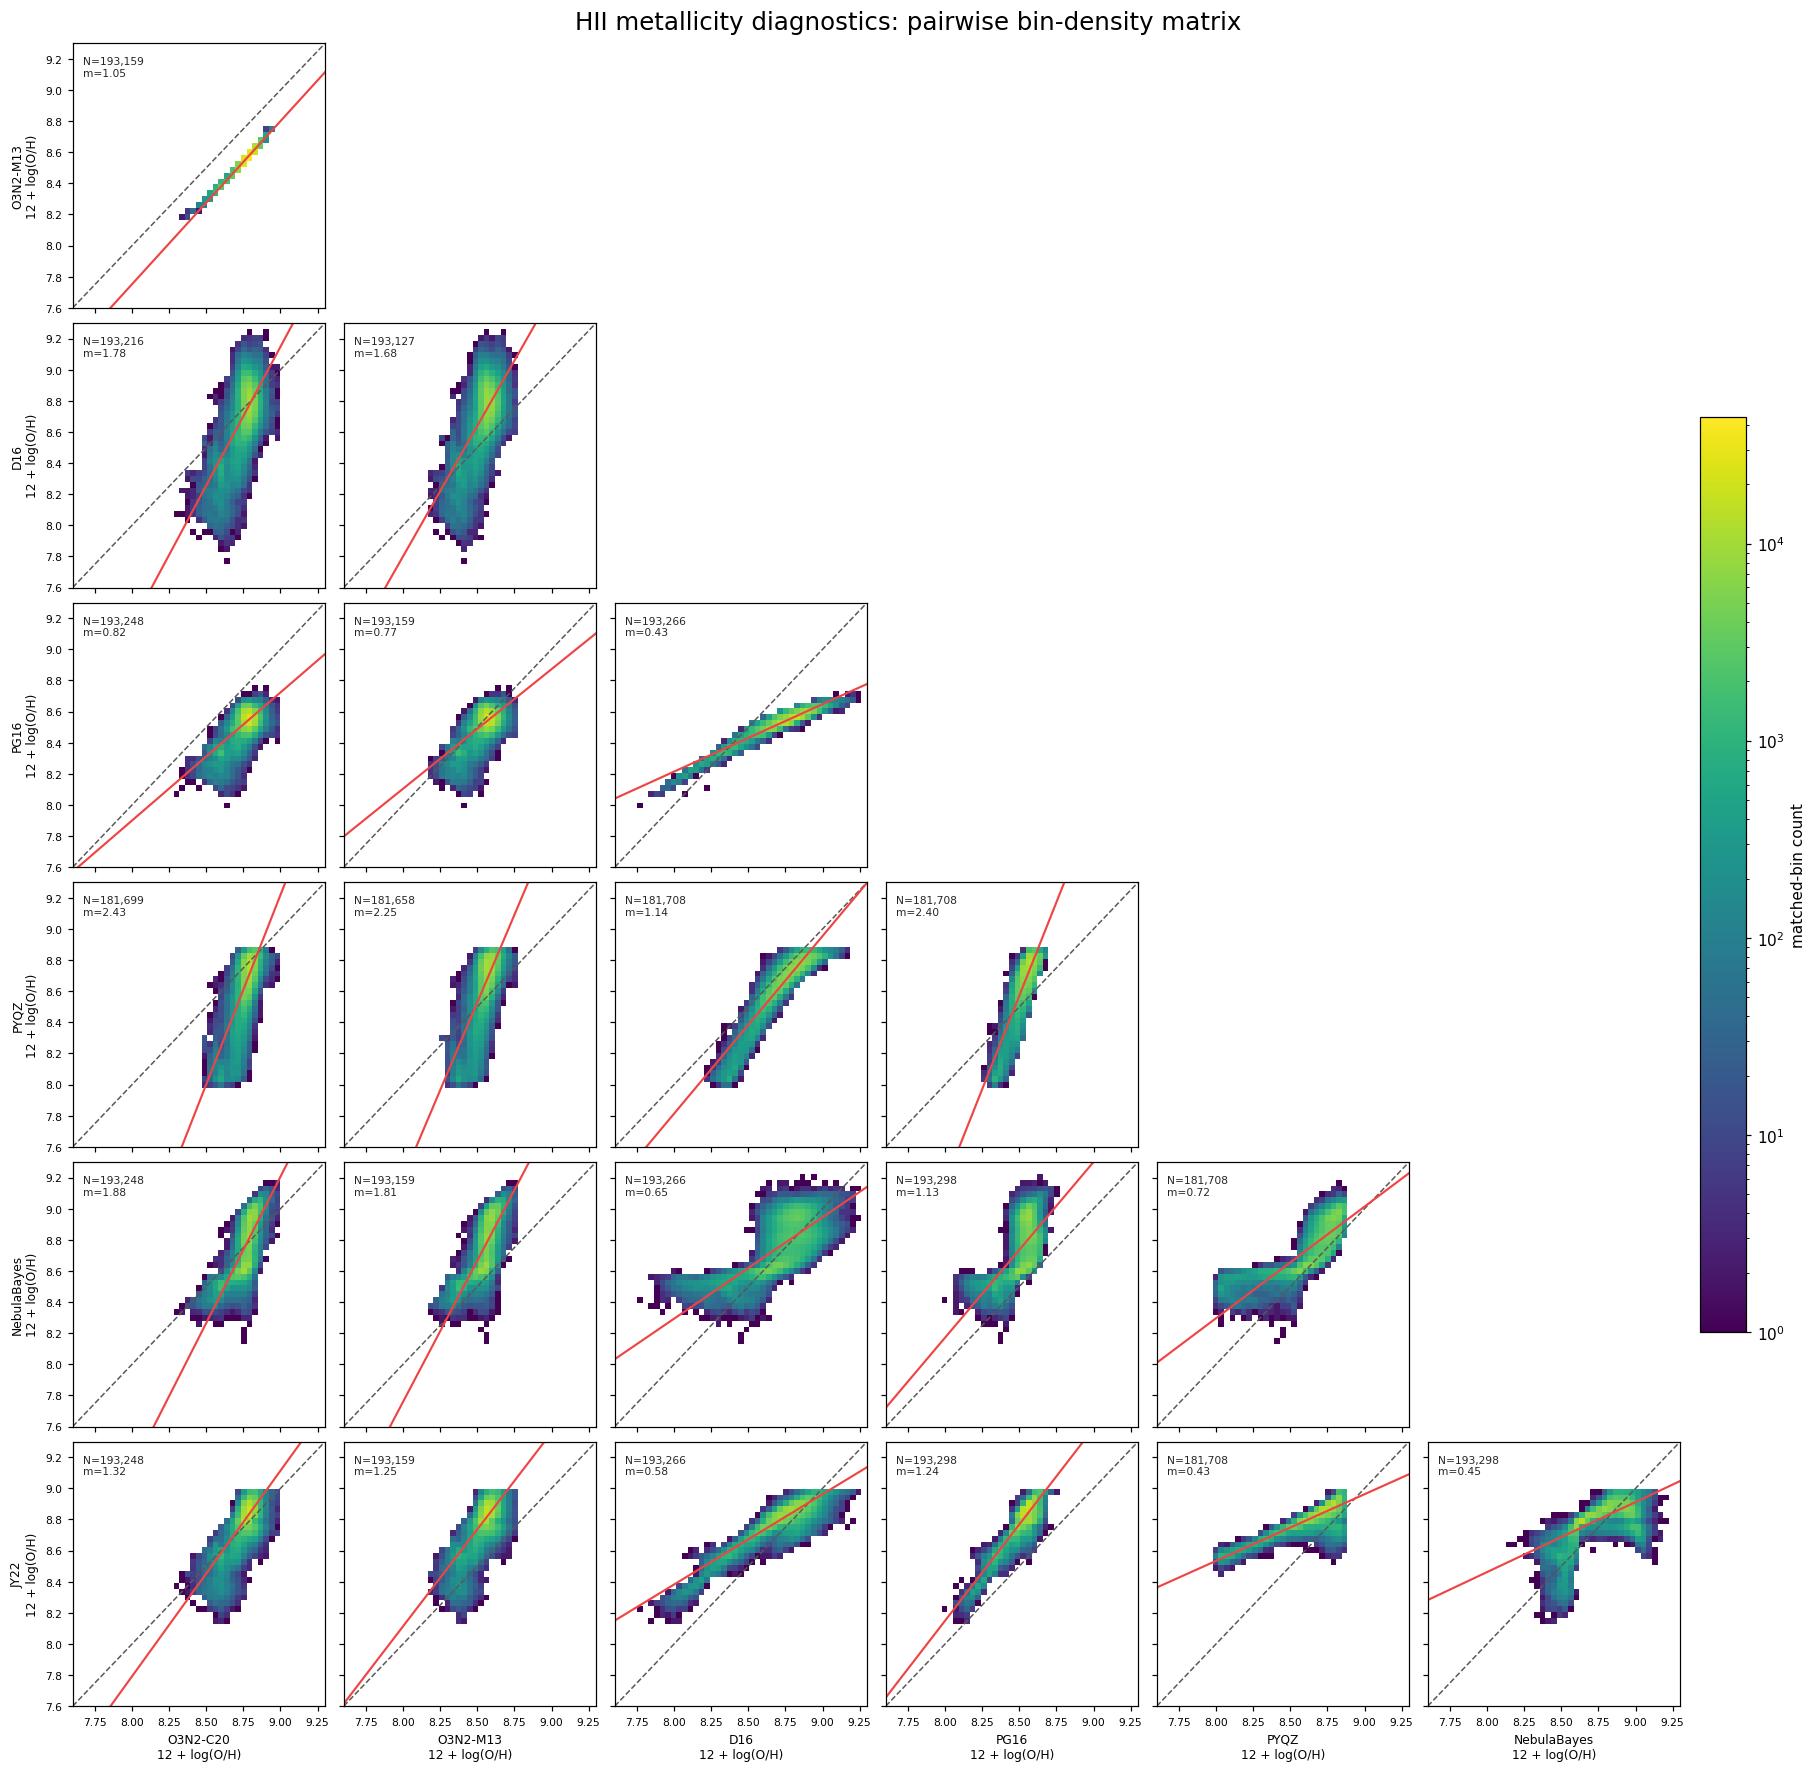

In [6]:
def matched_xy(frame: pd.DataFrame, x_name: str, y_name: str):
    x = frame[x_name].to_numpy(float)
    y = frame[y_name].to_numpy(float)
    good = np.isfinite(x) & np.isfinite(y)
    return x[good], y[good]


def pairwise_density_triangle(
    frame: pd.DataFrame,
    mapping: dict[str, str],
    limits: tuple[float, float],
    axis_label: str,
    title: str,
    bins_count: int = 45,
):
    labels = list(mapping)
    edges = np.linspace(limits[0], limits[1], bins_count + 1)
    payload = {}
    global_max = 1
    for i in range(1, len(labels)):
        for j in range(i):
            x, y = matched_xy(frame, labels[j], labels[i])
            counts, _, _ = np.histogram2d(x, y, bins=(edges, edges))
            payload[(i, j)] = (x, y, counts)
            global_max = max(global_max, int(counts.max(initial=0)))

    n_side = len(labels) - 1
    fig, axes = plt.subplots(
        n_side, n_side,
        figsize=(2.5 * n_side + 1.4, 2.5 * n_side + 1.0),
        sharex=True, sharey=True, constrained_layout=True,
    )
    axes = np.atleast_2d(axes)
    norm = LogNorm(vmin=1, vmax=max(global_max, 2))
    mesh = None

    for row in range(n_side):
        i = row + 1
        for col in range(n_side):
            ax = axes[row, col]
            if col >= i:
                ax.axis("off")
                continue
            x, y, counts = payload[(i, col)]
            masked = np.ma.masked_where(counts.T == 0, counts.T)
            mesh = ax.pcolormesh(edges, edges, masked, cmap="viridis", norm=norm, shading="auto")
            ax.plot(limits, limits, "--", color="0.35", lw=1)
            if x.size >= 3 and np.ptp(x) > 0:
                fit = linregress(x, y)
                xx = np.asarray(limits)
                ax.plot(xx, fit.intercept + fit.slope * xx, color="#ef4444", lw=1.4)
                ax.text(0.04, 0.95, f"N={x.size:,}\nm={fit.slope:.2f}", transform=ax.transAxes,
                        va="top", fontsize=7, color="0.15")
            else:
                ax.text(0.04, 0.95, f"N={x.size:,}", transform=ax.transAxes,
                        va="top", fontsize=7, color="0.15")
            ax.set_xlim(limits)
            ax.set_ylim(limits)
            ax.tick_params(labelsize=7)
            if col == 0:
                ax.set_ylabel(f"{labels[i]}\n{axis_label}", fontsize=8)
            if row == n_side - 1:
                ax.set_xlabel(f"{labels[col]}\n{axis_label}", fontsize=8)

    if mesh is not None:
        fig.colorbar(mesh, ax=axes.ravel().tolist(), shrink=0.55, pad=0.01, label="matched-bin count")
    fig.suptitle(title, fontsize=16)
    plt.show()
    return fig


metallicity_triangle = pairwise_density_triangle(
    metal_bins,
    METALLICITY_HDUS,
    limits=(7.6, 9.3),
    axis_label=r"12 + log(O/H)",
    title="HII metallicity diagnostics: pairwise bin-density matrix",
)


## 5. O3N2-C20-reference comparison

O3N2-C20 is now treated consistently as the x-axis reference. The summary reports candidate − O3N2-C20, so positive residuals mean that the candidate diagnostic gives a higher abundance. Correlations and fits are calculated only on matched finite bins. These are agreement diagnostics—not evidence that O3N2-C20 is the physically true abundance scale.

All samples in this section already satisfy the stored `_HII` footprint, `PROXY_EWHA > 6 Å`, and intrinsic Hα dispersion `< 45 km s⁻¹`.


,N,delta_p16,delta_median,delta_p84,RMSE,Spearman_rho,OLS_slope,OLS_intercept
diagnostic,,,,,,,,
O3N2-M13,193159,-0.2148,-0.2114,-0.2069,0.2108,1.0000,1.0481,-0.6327
D16,193216,-0.1545,-0.0230,0.1007,0.1434,0.3355,1.7832,-6.9010
PG16,193248,-0.2924,-0.2349,-0.1771,0.2436,0.2724,0.8231,1.3149
PYQZ,181699,-0.2064,-0.0702,0.0143,0.1714,0.5298,2.4349,-12.6940
NebulaBayes,193248,-0.1353,0.0092,0.1464,0.1230,0.6983,1.8803,-7.7169
JY22,193248,-0.0273,0.0504,0.1105,0.0872,0.5022,1.3217,-2.7814


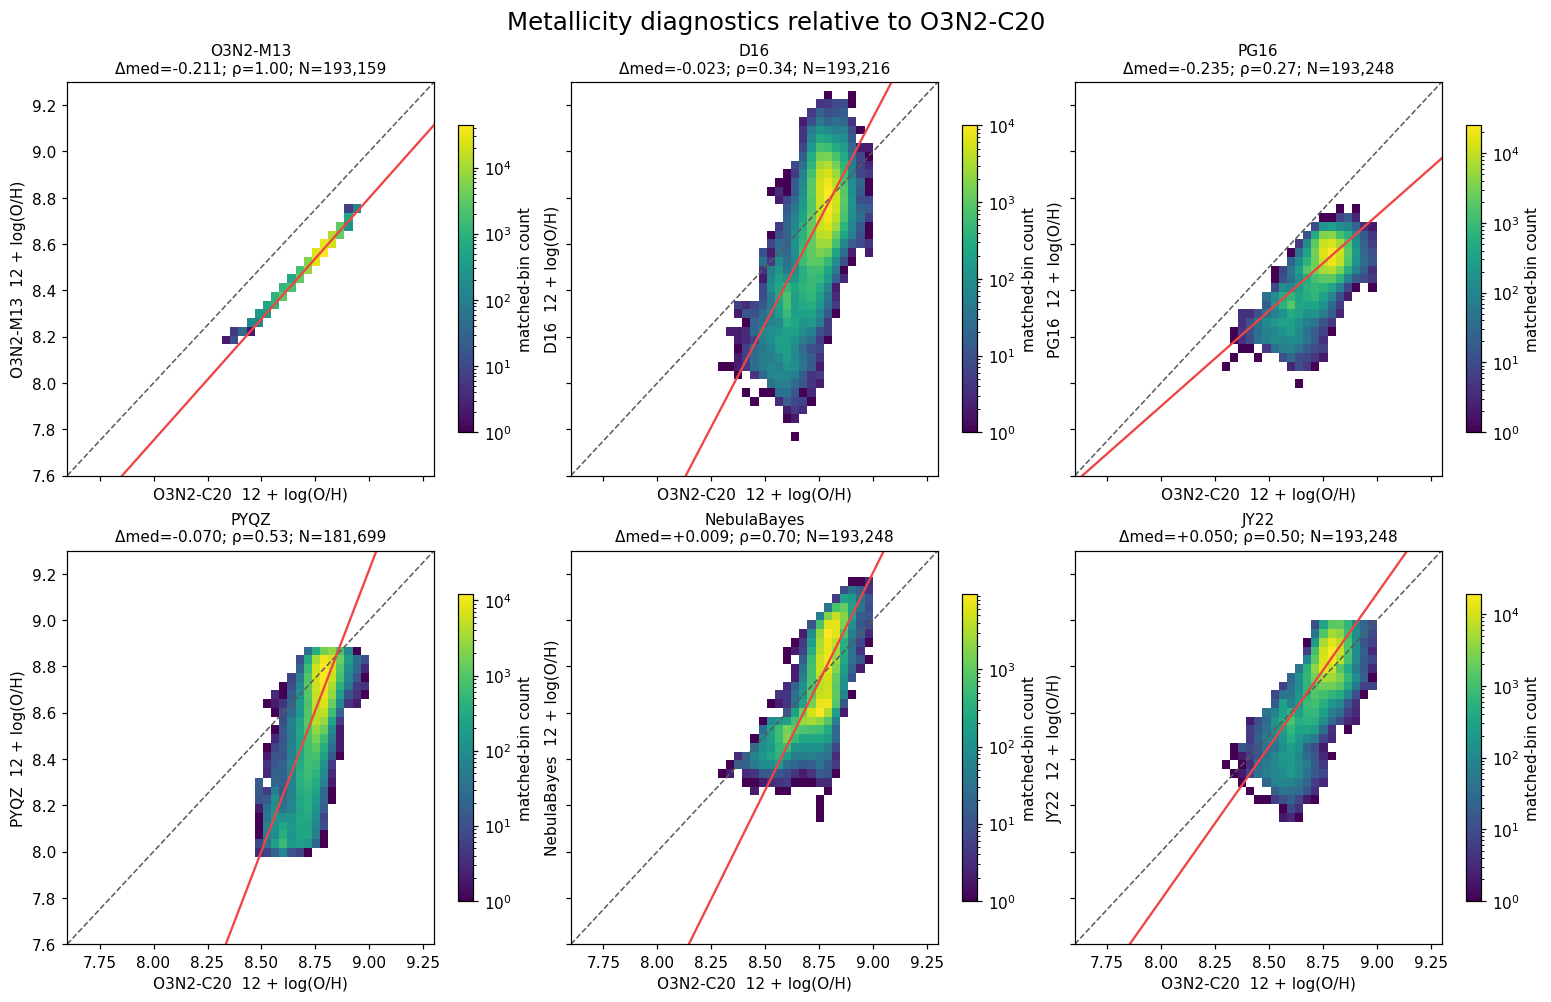

In [7]:
def reference_summary(frame: pd.DataFrame, reference_label: str) -> pd.DataFrame:
    rows = []
    for label in frame.columns:
        if label in ("galaxy", "BIN_ID", reference_label):
            continue
        x, y = matched_xy(frame, reference_label, label)
        if x.size == 0:
            rows.append({"diagnostic": label, "N": 0})
            continue
        delta = y - x
        fit = linregress(x, y) if x.size >= 3 and np.ptp(x) > 0 else None
        rho = spearmanr(x, y).statistic if x.size >= 3 else np.nan
        rows.append({
            "diagnostic": label,
            "N": x.size,
            "delta_p16": np.percentile(delta, 16),
            "delta_median": np.median(delta),
            "delta_p84": np.percentile(delta, 84),
            "RMSE": np.sqrt(np.mean(delta**2)),
            "Spearman_rho": rho,
            "OLS_slope": np.nan if fit is None else fit.slope,
            "OLS_intercept": np.nan if fit is None else fit.intercept,
        })
    return pd.DataFrame(rows).set_index("diagnostic")


c20_summary = reference_summary(metal_bins, REFERENCE_LABEL)
display(c20_summary.round(4))

candidate_labels = [name for name in METALLICITY_HDUS if name != REFERENCE_LABEL]
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True, constrained_layout=True)
edges = np.linspace(7.6, 9.3, 46)
for ax, label in zip(axes.ravel(), candidate_labels):
    x, y = matched_xy(metal_bins, REFERENCE_LABEL, label)
    counts, _, _ = np.histogram2d(x, y, bins=(edges, edges))
    masked = np.ma.masked_where(counts.T == 0, counts.T)
    image = ax.pcolormesh(edges, edges, masked, cmap="viridis", norm=LogNorm(vmin=1), shading="auto")
    ax.plot((7.6, 9.3), (7.6, 9.3), "--", color="0.35", lw=1)
    if x.size >= 3 and np.ptp(x) > 0:
        fit = linregress(x, y)
        xx = np.asarray((7.6, 9.3))
        ax.plot(xx, fit.intercept + fit.slope * xx, color="#ef4444", lw=1.5)
    stats = c20_summary.loc[label]
    ax.set_title(
        f"{label}\nΔmed={stats['delta_median']:+.3f}; ρ={stats['Spearman_rho']:.2f}; N={int(stats['N']):,}",
        fontsize=10,
    )
    ax.set_xlim(7.6, 9.3)
    ax.set_ylim(7.6, 9.3)
    ax.set_xlabel("O3N2-C20  12 + log(O/H)")
    ax.set_ylabel(f"{label}  12 + log(O/H)")
    fig.colorbar(image, ax=ax, shrink=0.78, label="matched-bin count")
fig.suptitle("Metallicity diagnostics relative to O3N2-C20", fontsize=16)
plt.show()


### Galaxy-by-galaxy median offsets from O3N2-C20

The pooled matrix can be dominated by galaxies with many fitted bins. This heat map gives every galaxy one row and displays its median matched-bin offset for each non-reference diagnostic. Blank entries mean that a diagnostic is unavailable or has no matched finite HII bins.


diagnostic,D16,JY22,NebulaBayes,O3N2-M13,PG16,PYQZ
galaxy,,,,,,
IC3392,0.010,0.075,0.107,-0.212,-0.233,-0.042
NGC4064,-0.098,0.027,0.075,-0.208,-0.295,-0.118
NGC4189,-0.140,0.008,-0.142,-0.213,-0.267,-0.219
NGC4192,-0.019,0.044,-0.099,-0.211,-0.206,-0.104
NGC4222,-0.331,-0.118,-0.148,-0.217,-0.326,-0.576
NGC4254,0.029,0.077,0.072,-0.211,-0.222,-0.024
NGC4293,0.096,0.074,0.197,-0.213,-0.202,0.027
NGC4294,-0.399,-0.160,-0.078,-0.212,-0.314,-0.480
NGC4298,-0.059,0.041,0.006,-0.211,-0.255,-0.105


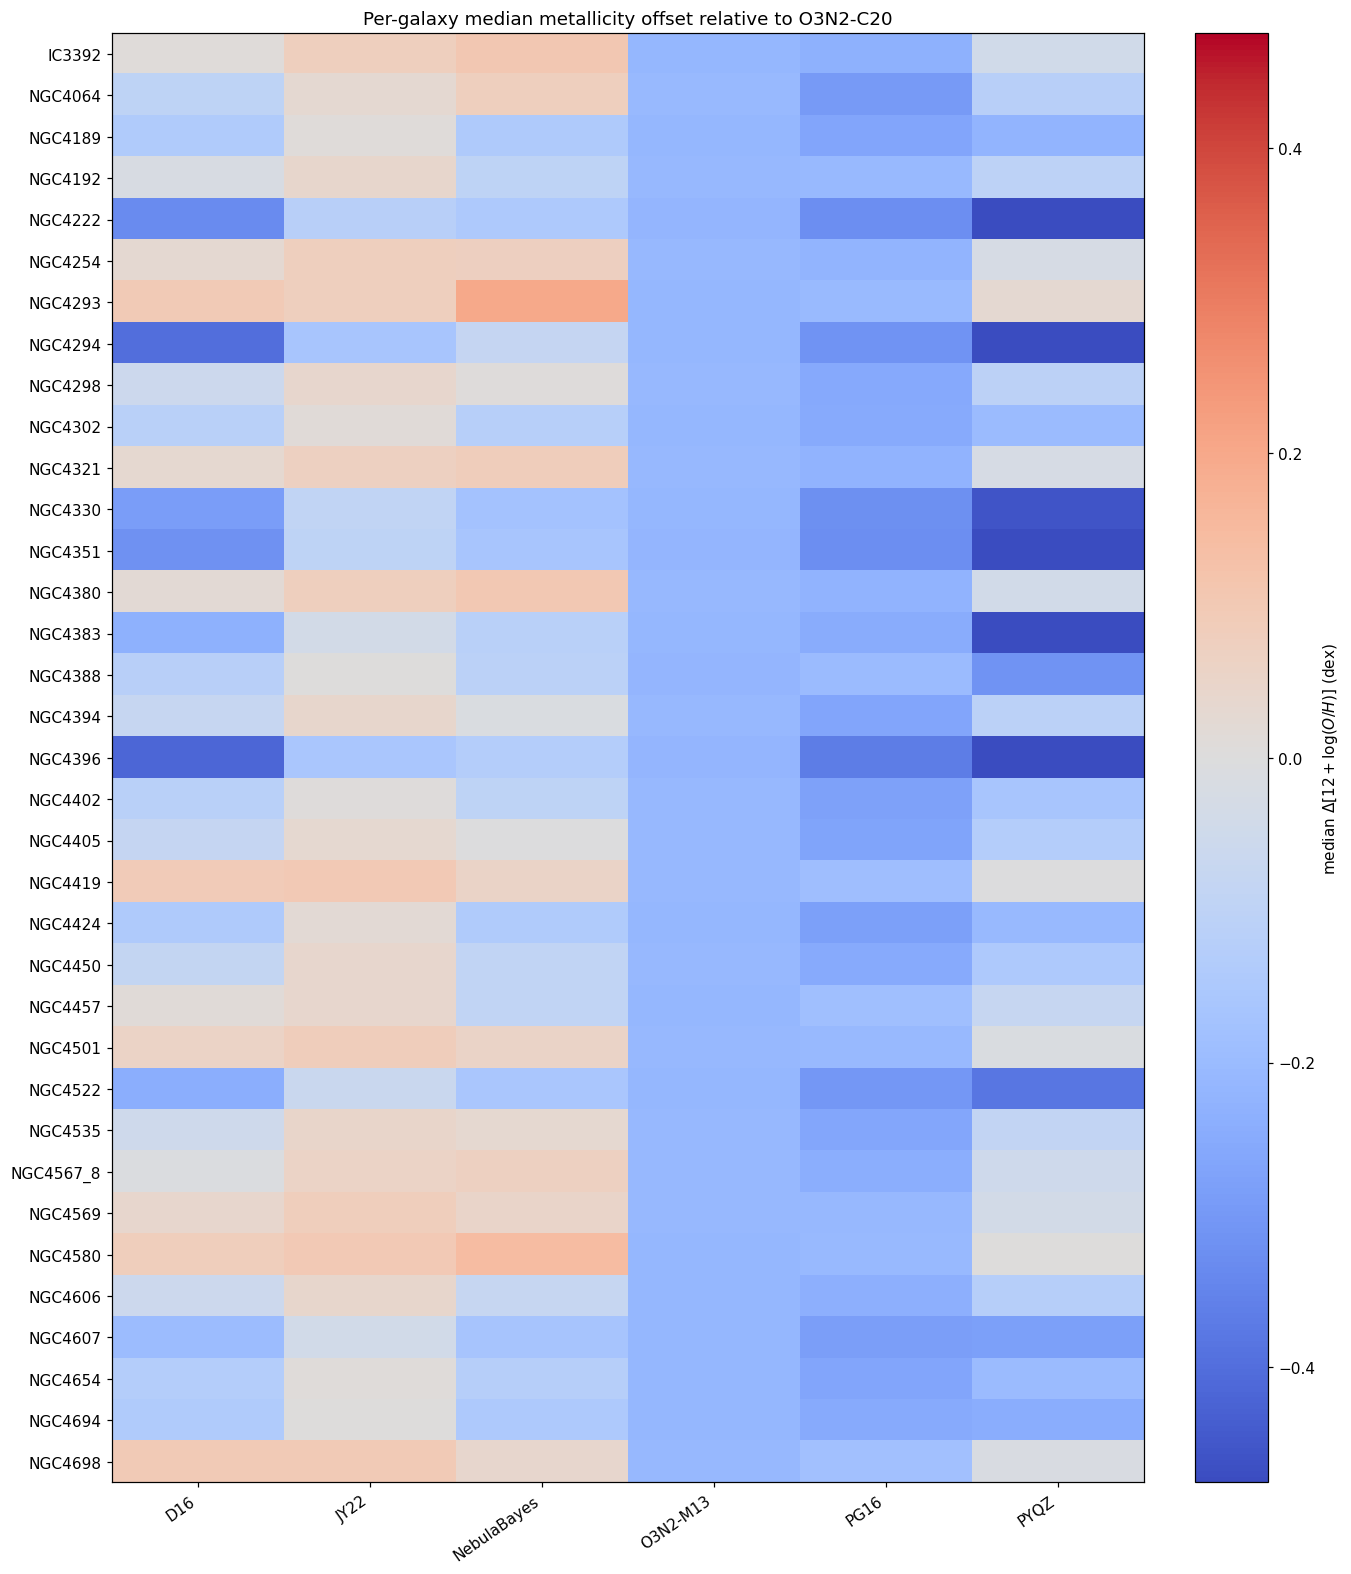

In [8]:
offset_rows = []
for galaxy, group in metal_bins.groupby("galaxy", sort=True):
    for label in candidate_labels:
        x, y = matched_xy(group, REFERENCE_LABEL, label)
        offset_rows.append({
            "galaxy": galaxy,
            "diagnostic": label,
            "median_delta": np.median(y - x) if x.size else np.nan,
            "N": x.size,
        })

galaxy_offsets_long = pd.DataFrame(offset_rows)
galaxy_offsets = galaxy_offsets_long.pivot(index="galaxy", columns="diagnostic", values="median_delta")
display(galaxy_offsets.round(3))

finite_offsets = galaxy_offsets.to_numpy(float)
finite_offsets = finite_offsets[np.isfinite(finite_offsets)]
if finite_offsets.size:
    limit = max(0.05, float(np.percentile(np.abs(finite_offsets), 98)))
    fig, ax = plt.subplots(
        figsize=(1.45 * len(galaxy_offsets.columns) + 3.5, 0.34 * len(galaxy_offsets.index) + 2.3),
        constrained_layout=True,
    )
    image = ax.imshow(
        galaxy_offsets.to_numpy(float), aspect="auto", cmap="coolwarm",
        norm=TwoSlopeNorm(vmin=-limit, vcenter=0.0, vmax=limit),
        interpolation="nearest",
    )
    ax.set_xticks(np.arange(len(galaxy_offsets.columns)), galaxy_offsets.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(galaxy_offsets.index)), galaxy_offsets.index)
    ax.set_title("Per-galaxy median metallicity offset relative to O3N2-C20")
    fig.colorbar(image, ax=ax, label=r"median $\Delta[12+\log(O/H)]$ (dex)")
    plt.show()
else:
    print("No finite O3N2-C20 comparison pairs are available yet.")


## 6. Exploratory ionization-parameter comparison

PYQZ, NebulaBayes, and JY22 all report a quantity called log U, but they do not infer it from the same grid, abundance prescription, line set, prior, or posterior estimator. Therefore, the panels below test ordering, range, saturation, and spatial-bin agreement only. A non-zero offset should not be interpreted as a simple measurement bias until the model definitions and parameter conventions have been harmonized.

PYQZ also stores `LOG_Q_PYQZ_HII`; this notebook uses its derived `LOG_U_PYQZ_HII` so that all three axes have the same nominal quantity.

All samples in this section already satisfy the stored `_HII` footprint, `PROXY_EWHA > 6 Å`, and intrinsic Hα dispersion `< 45 km s⁻¹`.


Ionization table: 193,298 unique galaxy-bin rows


,count,median,min,max
PYQZ,181708.0,-3.382901,-3.959583,-2.516973
NebulaBayes,193298.0,-3.078087,-3.858385,-2.205364
JY22,193298.0,-1.169221,-3.106536,-0.500000


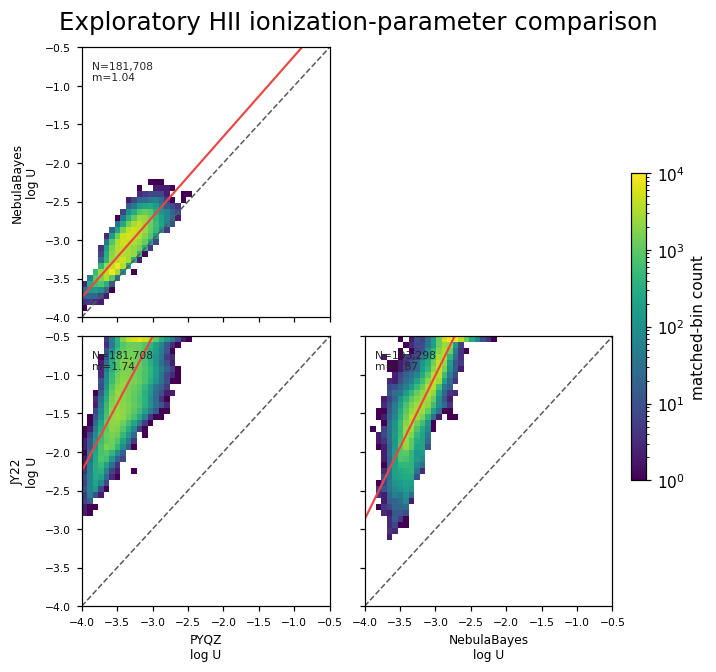

,N,delta_p16,delta_median,delta_p84,Spearman_rho
comparison,,,,,
NebulaBayes - PYQZ,181708,0.1410,0.2798,0.4284,0.8349
JY22 - PYQZ,181708,1.8231,2.2043,2.6285,0.6966
JY22 - NebulaBayes,193298,1.6463,1.9349,2.2132,0.9360


In [9]:
ionization_bins = collect_representative_bins(IONIZATION_HDUS)
print(f"Ionization table: {len(ionization_bins):,} unique galaxy-bin rows")
display(
    ionization_bins[list(IONIZATION_HDUS)].agg(["count", "median", "min", "max"]).T
)

ionization_triangle = pairwise_density_triangle(
    ionization_bins,
    IONIZATION_HDUS,
    limits=(-4.0, -0.5),
    axis_label="log U",
    title="Exploratory HII ionization-parameter comparison",
    bins_count=45,
)

ion_rows = []
ion_labels = list(IONIZATION_HDUS)
for i in range(1, len(ion_labels)):
    for j in range(i):
        x_name, y_name = ion_labels[j], ion_labels[i]
        x, y = matched_xy(ionization_bins, x_name, y_name)
        delta = y - x
        ion_rows.append({
            "comparison": f"{y_name} - {x_name}",
            "N": x.size,
            "delta_p16": np.percentile(delta, 16) if x.size else np.nan,
            "delta_median": np.median(delta) if x.size else np.nan,
            "delta_p84": np.percentile(delta, 84) if x.size else np.nan,
            "Spearman_rho": spearmanr(x, y).statistic if x.size >= 3 else np.nan,
        })
ionization_summary = pd.DataFrame(ion_rows).set_index("comparison")
display(ionization_summary.round(4))


## 7. Reading the results and next checks

Recommended order of interpretation after all products finish downloading:

1. **Availability first:** confirm that each diagnostic has the expected number of galaxies and bins after the `_HII + EW + intrinsic-sigma` selection. Missing panels are a data-completeness issue, not a physical result.
2. **Map morphology:** compare the three method-grouped fixed-scale mosaics and their seven mini-panels for gradients, discontinuities, grid-edge saturation, and galaxy-specific failures.
3. **O3N2-C20 agreement:** use the dedicated summary for median offset, scatter, rank preservation, and response slope. Inspect the galaxy-offset heat map before quoting a pooled result.
4. **All-calibrator structure:** use the lower triangle to identify diagnostic families that compress the range, form discrete model-grid ridges, curve away from equality, or separate into multiple loci.
5. **Ionization only after provenance checks:** compare log U trends cautiously; pressure is only inferred by NebulaBayes, while PYQZ's pressure is fixed model provenance and is therefore not plotted as an inferred map.

The requested star-forming quality selection is already applied consistently to maps, metallicity tables, O3N2-C20 comparisons, per-galaxy offsets, and log-U comparisons. Before paper use, decide explicitly whether to add method-specific reliability flags, radial coverage, uncertainty cuts, or other narrower QC; none of those additional cuts is silently applied here.
